In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

from george import kernels
import george
from astropy.io import fits
from functions import *
from gp_model_params import info
from glob import glob
from tqdm import tqdm
import pickle as pkl
from scipy.signal import find_peaks

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/somayeh/opt/anaconda3/envs/pyt38/lib/python3.8/site-packages/george/metrics.py:103: RuntimeWarning: divide by zero encountered in log
  parameters.append(np.log(metric))
/Users/somayeh/opt/anaconda3/envs/pyt38/lib/python3.8/site-packages/george/metrics.py:103: RuntimeWarning: invalid value encountered in log
  parameters.append(np.log(metric))


In [2]:
from pathlib import Path
home = str(Path.home())

In [3]:
# Define variable type and ID
tp = 'CV'
file_format = '.dat'
id_ = '062036'

In [4]:
# Set directory paths and read period data
direc = home+'/Research_data/Bulge_Variables/%s/'%tp
direc_list = np.sort(glob(direc+'*%s'%file_format))

In [5]:
name = home+'/Research_data/Bulge_Variables/%s/OGLE-BLG-DN-0001.dat'%tp

In [6]:
# Identify data file and extract period information
index = np.where(direc_list == name)[0][0]
path = direc_list[index]
ID = path.split('/')[-1].split('_')[0]
band = 'I'

In [9]:
t, m, merr = np.loadtxt(path)[:,0], np.loadtxt(path)[:,1], np.loadtxt(path)[:,2]

(5350.0, 5400.0)

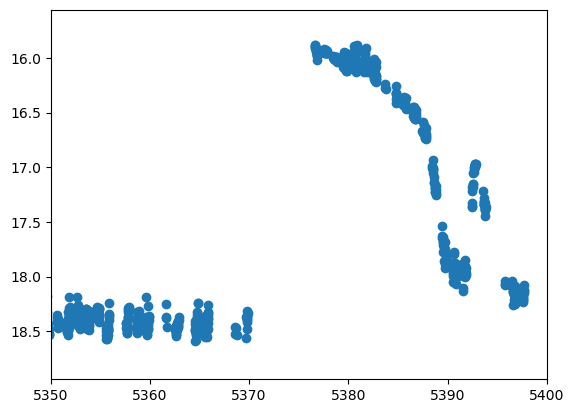

In [10]:
plt.scatter(t, m)
plt.gca().invert_yaxis()
plt.xlim(5350, 5400)